# 02 Alarm Generation

In [1]:
# load parquet data 

import pandas as pd
import numpy as np

from pathlib import Path

DATA_PATH = "../data/interim/data_sorted.parquet"

df = pd.read_parquet(DATA_PATH)

df.shape

(1737585, 14)

In [ ]:
# configuration

TARGET = "03TIC_1009.PV"

THRESHOLDS = [
    30,
    30.5,
    31,
    31.5,
    32
]

GROUP_GAP_MINUTES = 30

In [4]:
# create raw alarm events

def extract_raw_alarms(
    df,
    threshold,
    target_col="03TIC_1009.PV"
):
    
    alarm_mask = (
        df[target_col] < threshold
    )
    
    event_id = (
        alarm_mask.ne(
            alarm_mask.shift()
        )
        .cumsum()
    )
    
    alarms = []

    for _, group in (
        df[alarm_mask]
        .groupby(event_id)
    ):
        
        alarms.append({
            "start_time":
                group["TimeStamp"].iloc[0],
            
            "end_time":
                group["TimeStamp"].iloc[-1],
            
            "duration_minutes":
                len(group)
        })
    
    return pd.DataFrame(alarms)

In [5]:
# apply 30-min grouping

def group_alarm_events(
    alarms,
    gap_minutes=30
):
    
    if len(alarms) == 0:
        return alarms
    
    alarms = alarms.sort_values(
        "start_time"
    )
    
    grouped = []

    current_start = alarms.iloc[0]["start_time"]
    current_end = alarms.iloc[0]["end_time"]

    for i in range(1, len(alarms)):
        
        next_start = alarms.iloc[i]["start_time"]
        next_end = alarms.iloc[i]["end_time"]

        gap = (
            next_start - current_end
        ).total_seconds() / 60

        if gap <= gap_minutes:
            
            current_end = max(
                current_end,
                next_end
            )
        
        else:
            
            grouped.append({
                "start_time":
                    current_start,
                
                "end_time":
                    current_end
            })

            current_start = next_start
            current_end = next_end

    grouped.append({
        "start_time":
            current_start,
        "end_time":
            current_end
    })

    grouped = pd.DataFrame(grouped)

    grouped[
        "duration_minutes"
    ] = (
        grouped["end_time"]
        - grouped["start_time"]
    ).dt.total_seconds() / 60

    return grouped

In [6]:
# threshold study

results = []

for threshold in THRESHOLDS:

    raw_alarms = extract_raw_alarms(
        df,
        threshold
    )

    grouped_alarms = (
        group_alarm_events(
            raw_alarms,
            GROUP_GAP_MINUTES
        )
    )

    results.append({
        "threshold":
            threshold,

        "raw_alarm_count":
            len(raw_alarms),

        "grouped_alarm_count":
            len(grouped_alarms),

        "mean_duration":
            grouped_alarms[
                "duration_minutes"
            ].mean(),

        "median_duration":
            grouped_alarms[
                "duration_minutes"
            ].median(),

        "max_duration":
            grouped_alarms[
                "duration_minutes"
            ].max()
    })

    grouped_alarms.to_csv(
        f"../outputs/reports/alarm_events_{threshold}.csv",
        index=False
    )

In [7]:
# summary table

summary = pd.DataFrame(
    results
)

summary

,threshold,raw_alarm_count,grouped_alarm_count,mean_duration,median_duration,max_duration
0,30.0,75,28,17.071429,0.0,134.0
1,30.5,125,46,17.478261,0.0,138.0
2,31.0,288,70,29.500000,0.0,493.0
3,31.5,689,89,52.662921,3.0,1432.0
4,32.0,1292,136,53.580882,0.0,1749.0


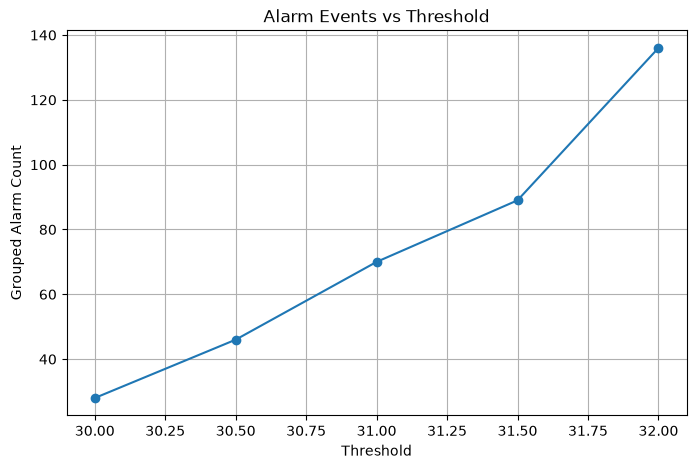

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    summary["threshold"],
    summary["grouped_alarm_count"],
    marker="o"
)

plt.xlabel("Threshold")
plt.ylabel("Grouped Alarm Count")

plt.title(
    "Alarm Events vs Threshold"
)

plt.grid(True)

plt.show()

In [9]:
grouped_alarms.sort_values(
    "duration_minutes",
    ascending=False
).head(20)

,start_time,end_time,duration_minutes
32,2024-10-15 21:25:00,2024-10-17 02:34:00,1749.0
98,2024-11-28 18:02:00,2024-11-29 13:12:00,1150.0
99,2024-11-29 13:57:00,2024-11-30 08:59:00,1142.0
101,2024-11-30 13:38:00,2024-12-01 08:13:00,1115.0
5,2022-03-28 01:20:00,2022-03-28 08:43:00,443.0
100,2024-11-30 09:33:00,2024-11-30 13:05:00,212.0
39,2024-10-24 08:45:00,2024-10-24 11:05:00,140.0
26,2024-10-15 09:10:00,2024-10-15 11:01:00,111.0
25,2024-10-15 06:36:00,2024-10-15 08:22:00,106.0
19,2024-04-16 05:56:00,2024-04-16 07:38:00,102.0


In [10]:
grouped_alarms["duration_minutes"].describe()

count     136.000000
mean       53.580882
std       225.657248
min         0.000000
25%         0.000000
50%         0.000000
75%        15.000000
max      1749.000000
Name: duration_minutes, dtype: float64